In [1]:
import sys
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score ,recall_score ,precision_score,confusion_matrix
sys.path.append(str(Path("..")))
from src.dataset import train_data, train_loader, val_loader, ood_loader,ood_path
from torchvision import transforms,datasets
from torch.utils.data import Subset,DataLoader
import matplotlib.pyplot as plt
import seaborn as sns

torch.Size([32, 3, 256, 256])
torch.Size([32])
tensor([3, 3, 1, 2, 5, 7, 3, 2, 5, 5])


In [2]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print(device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [3]:
class CNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 32 * 32, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)

        return x
    
    
    
num_classes = len(train_data.classes)

model = CNN(num_classes)
model = model.to(device)



criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)





In [4]:
num_epochs = 100

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

val_f1_scores = []
val_precision_scores = []
val_recall_scores = []

val_f1_scores_by_class = []
val_precision_scores_by_class = []
val_recall_scores_by_class = []

best_val_f1 = 0.0
best_epoch = 0



for epoch in range(num_epochs):

    # =========================
    # Train
    # =========================

    model.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()

    train_loss = running_train_loss / len(train_loader)

    train_accuracy = train_correct / train_total




    model.eval()

    running_val_loss = 0.0

    val_correct = 0
    val_total = 0

    all_val_labels = []
    all_val_predictions = []


    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_val_loss += loss.item()


            _, predicted = torch.max(
                outputs,
                1
            )

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()


            all_val_labels.extend(
                labels.cpu().numpy()
            )

            all_val_predictions.extend(
                predicted.cpu().numpy()
            )


    val_loss = (
        running_val_loss /
        len(val_loader)
    )

    val_accuracy = (
        val_correct /
        val_total
    )

    val_f1 = f1_score(
        all_val_labels,
        all_val_predictions,
        average="macro",
        zero_division=0
    )

    val_precision = precision_score(
        all_val_labels,
        all_val_predictions,
        average="macro",
        zero_division=0
    )

    val_recall = recall_score(
        all_val_labels,
        all_val_predictions,
        average="macro",
        zero_division=0
    )


    f1_score_by_class = f1_score(
        all_val_labels,
        all_val_predictions,
        average=None,
        zero_division=0
    )

    precision_by_class = precision_score(
        all_val_labels,
        all_val_predictions,
        average=None,
        zero_division=0
    )

    recall_by_class = recall_score(
        all_val_labels,
        all_val_predictions,
        average=None,
        zero_division=0
    )




    train_losses.append(
        train_loss
    )

    train_accuracies.append(
        train_accuracy
    )

    val_losses.append(
        val_loss
    )

    val_accuracies.append(
        val_accuracy
    )

    val_f1_scores.append(
        val_f1
    )

    val_precision_scores.append(
        val_precision
    )

    val_recall_scores.append(
        val_recall
    )

    val_f1_scores_by_class.append(
        f1_score_by_class
    )

    val_precision_scores_by_class.append(
        precision_by_class
    )

    val_recall_scores_by_class.append(
        recall_by_class
    )


    print(
        f"Epoch [{epoch + 1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Val Precision: {val_precision:.4f} | "
        f"Val Recall: {val_recall:.4f} | "
        f"Val Macro F1: {val_f1:.4f}"
    )

    print("Precision by each class:")
    print(precision_by_class)

    print("Recall by each class:")
    print(recall_by_class)

    print("F1 Score by each class:")
    print(f1_score_by_class)
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            "../models/baseline.pth"
        )

        print(
        f"Best model saved! "
        f"Epoch: {best_epoch} | "
        f"Val Macro F1: {best_val_f1:.4f}"
        )

Epoch [1/100] | Train Loss: 1.5248 | Train Acc: 0.4849 | Val Loss: 0.9817 | Val Acc: 0.6575 | Val Precision: 0.7297 | Val Recall: 0.6180 | Val Macro F1: 0.6049
Precision by each class:
[0.44242424 0.64179104 0.84615385 0.66101695 0.6344086  0.68148148
 0.93       1.        ]
Recall by each class:
[0.9125     0.82692308 0.34375    0.35454545 0.64130435 0.82882883
 0.86915888 0.16666667]
F1 Score by each class:
[0.59591837 0.72268908 0.48888889 0.46153846 0.63783784 0.74796748
 0.89855072 0.28571429]


Best model saved! Epoch: 1 | Val Macro F1: 0.6049


Epoch [2/100] | Train Loss: 0.6402 | Train Acc: 0.7781 | Val Loss: 0.5316 | Val Acc: 0.8068 | Val Precision: 0.8006 | Val Recall: 0.7890 | Val Macro F1: 0.7928
Precision by each class:
[0.78888889 0.86597938 0.73469388 0.72477064 0.81927711 0.82608696
 0.89473684 0.75      ]
Recall by each class:
[0.8875     0.80769231 0.75       0.71818182 0.73913043 0.85585586
 0.95327103 0.6       ]
F1 Score by each class:
[0.83529412 0.8358209  0.74226804 0.72146119 0.77714286 0.84070796
 0.92307692 0.66666667]
Best model saved! Epoch: 2 | Val Macro F1: 0.7928


Epoch [3/100] | Train Loss: 0.3570 | Train Acc: 0.8795 | Val Loss: 0.5376 | Val Acc: 0.8055 | Val Precision: 0.8256 | Val Recall: 0.7874 | Val Macro F1: 0.7978
Precision by each class:
[0.92857143 0.73484848 0.78571429 0.63758389 0.89285714 0.83333333
 1.         0.79166667]
Recall by each class:
[0.8125     0.93269231 0.57291667 0.86363636 0.81521739 0.85585586
 0.81308411 0.63333333]
F1 Score by each class:
[0.86666667 0.8220339  0.6626506  0.73359073 0.85227273 0.84444444
 0.89690722 0.7037037 ]
Best model saved! Epoch: 3 | Val Macro F1: 0.7978


Epoch [4/100] | Train Loss: 0.1593 | Train Acc: 0.9452 | Val Loss: 0.6495 | Val Acc: 0.8151 | Val Precision: 0.8151 | Val Recall: 0.8039 | Val Macro F1: 0.8049
Precision by each class:
[0.89473684 0.80508475 0.67241379 0.76363636 0.94029851 0.78813559
 1.         0.65625   ]
Recall by each class:
[0.85       0.91346154 0.8125     0.76363636 0.68478261 0.83783784
 0.86915888 0.7       ]
F1 Score by each class:
[0.87179487 0.85585586 0.73584906 0.76363636 0.79245283 0.81222707
 0.93       0.67741935]
Best model saved! Epoch: 4 | Val Macro F1: 0.8049


...

Epoch [96/100] | Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 1.1831 | Val Acc: 0.8562 | Val Precision: 0.8545 | Val Recall: 0.8418 | Val Macro F1: 0.8472
Precision by each class:
[0.88888889 0.8952381  0.75757576 0.73109244 0.89156627 0.89285714
 0.97142857 0.80769231]
Recall by each class:
[0.9        0.90384615 0.78125    0.79090909 0.80434783 0.9009009
 0.95327103 0.7       ]
F1 Score by each class:
[0.89440994 0.89952153 0.76923077 0.75982533 0.84571429 0.89686099
 0.96226415 0.75      ]


Epoch [97/100] | Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 1.1859 | Val Acc: 0.8562 | Val Precision: 0.8545 | Val Recall: 0.8418 | Val Macro F1: 0.8472
Precision by each class:
[0.88888889 0.8952381  0.75757576 0.73109244 0.89156627 0.89285714
 0.97142857 0.80769231]
Recall by each class:
[0.9        0.90384615 0.78125    0.79090909 0.80434783 0.9009009
 0.95327103 0.7       ]
F1 Score by each class:
[0.89440994 0.89952153 0.76923077 0.75982533 0.84571429 0.89686099
 0.96226415 0.75      ]


Epoch [98/100] | Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 1.1890 | Val Acc: 0.8548 | Val Precision: 0.8532 | Val Recall: 0.8405 | Val Macro F1: 0.8459
Precision by each class:
[0.88888889 0.88679245 0.75510204 0.73109244 0.89156627 0.89285714
 0.97142857 0.80769231]
Recall by each class:
[0.9        0.90384615 0.77083333 0.79090909 0.80434783 0.9009009
 0.95327103 0.7       ]
F1 Score by each class:
[0.89440994 0.8952381  0.7628866  0.75982533 0.84571429 0.89686099
 0.96226415 0.75      ]


Epoch [99/100] | Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 1.1920 | Val Acc: 0.8548 | Val Precision: 0.8532 | Val Recall: 0.8405 | Val Macro F1: 0.8459
Precision by each class:
[0.88888889 0.88679245 0.75510204 0.73109244 0.89156627 0.89285714
 0.97142857 0.80769231]
Recall by each class:
[0.9        0.90384615 0.77083333 0.79090909 0.80434783 0.9009009
 0.95327103 0.7       ]
F1 Score by each class:
[0.89440994 0.8952381  0.7628866  0.75982533 0.84571429 0.89686099
 0.96226415 0.75      ]


Epoch [100/100] | Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 1.1950 | Val Acc: 0.8548 | Val Precision: 0.8532 | Val Recall: 0.8405 | Val Macro F1: 0.8459
Precision by each class:
[0.88888889 0.88679245 0.75510204 0.73109244 0.89156627 0.89285714
 0.97142857 0.80769231]
Recall by each class:
[0.9        0.90384615 0.77083333 0.79090909 0.80434783 0.9009009
 0.95327103 0.7       ]
F1 Score by each class:
[0.89440994 0.8952381  0.7628866  0.75982533 0.84571429 0.89686099
 0.96226415 0.75      ]


In [5]:

num_classes = len(train_data.classes)

model = CNN(num_classes)
model = model.to(device)

model.load_state_dict(
    torch.load("../models/baseline.pth")
)

model = model.to(device)

In [6]:
model.eval()


all_val_labels = []

all_val_predictions = []

# Probability of all 8 classes
all_probabilities = []

# Logits of all 8 classes
all_logits = []

val_correct = 0

val_total = 0


classes = train_data.classes


truck_id = classes.index("kamyun")

truckette_id = classes.index("kamyunet")

van_id = classes.index("vanet")


with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        labels = labels.to(device)


        outputs = model(images)


        probabilities = torch.softmax(

            outputs,

            dim=1

        )


        _, predicted = torch.max(

            outputs,

            1

        )


        val_total += labels.size(0)


        val_correct += (

            predicted == labels

        ).sum().item()


        all_val_labels.extend(

            labels.cpu().numpy()

        )


        all_val_predictions.extend(

            predicted.cpu().numpy()

        )


        # Save probabilities for all 8 classes

        all_probabilities.extend(

            probabilities.cpu().numpy()

        )


        # Save logits for all 8 classes

        all_logits.extend(

            outputs.cpu().numpy()

        )


val_accuracy = val_correct / val_total


val_precision = precision_score(

    all_val_labels,

    all_val_predictions,

    average="macro",

    zero_division=0

)


val_recall = recall_score(

    all_val_labels,

    all_val_predictions,

    average="macro",

    zero_division=0

)


val_f1 = f1_score(

    all_val_labels,

    all_val_predictions,

    average="macro",

    zero_division=0

)


val_precision_by_class = precision_score(

    all_val_labels,

    all_val_predictions,

    average=None,

    zero_division=0

)


val_recall_by_class = recall_score(

    all_val_labels,

    all_val_predictions,

    average=None,

    zero_division=0

)


val_f1_by_class = f1_score(

    all_val_labels,

    all_val_predictions,

    average=None,

    zero_division=0

)


# =========================
# val Results
# =========================

print(f"val Accuracy: {val_accuracy:.4f}")


print(

    f"val Macro Precision: "

    f"{val_precision:.4f}"

)


print(

    f"val Macro Recall: "

    f"{val_recall:.4f}"

)


print(

    f"val Macro F1: "

    f"{val_f1:.4f}"

)


print("val Precision by class:")

print(val_precision_by_class)


print("val Recall by class:")

print(val_recall_by_class)


print("val F1 by class:")

print(val_f1_by_class)

val Accuracy: 0.8521
val Macro Precision: 0.8613
val Macro Recall: 0.8492
val Macro F1: 0.8510
val Precision by class:
[0.94805195 0.91346154 0.61481481 0.75925926 0.90123457 0.98913043
 0.99019608 0.77419355]
val Recall by class:
[0.9125     0.91346154 0.86458333 0.74545455 0.79347826 0.81981982
 0.94392523 0.8       ]
val F1 by class:
[0.92993631 0.91346154 0.71861472 0.75229358 0.84393064 0.89655172
 0.96650718 0.78688525]


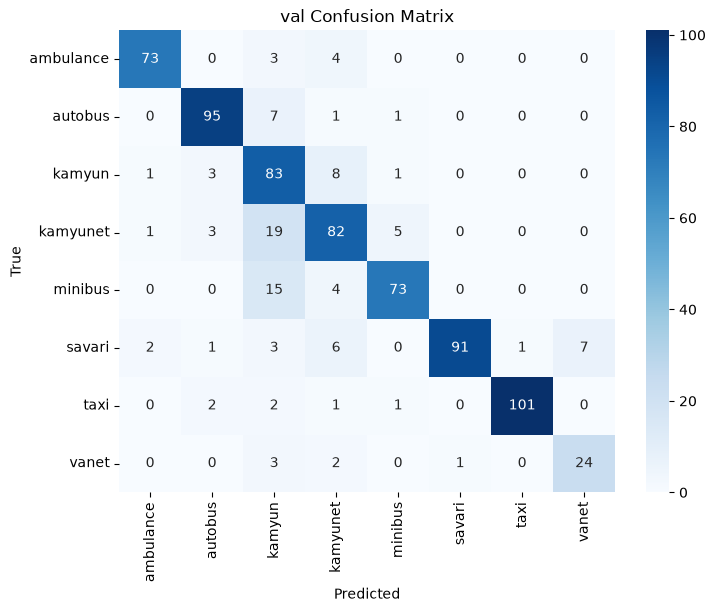

In [7]:
cm = confusion_matrix(
    all_val_labels,
    all_val_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_data.classes,
    yticklabels=train_data.classes
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("val Confusion Matrix")

plt.show()

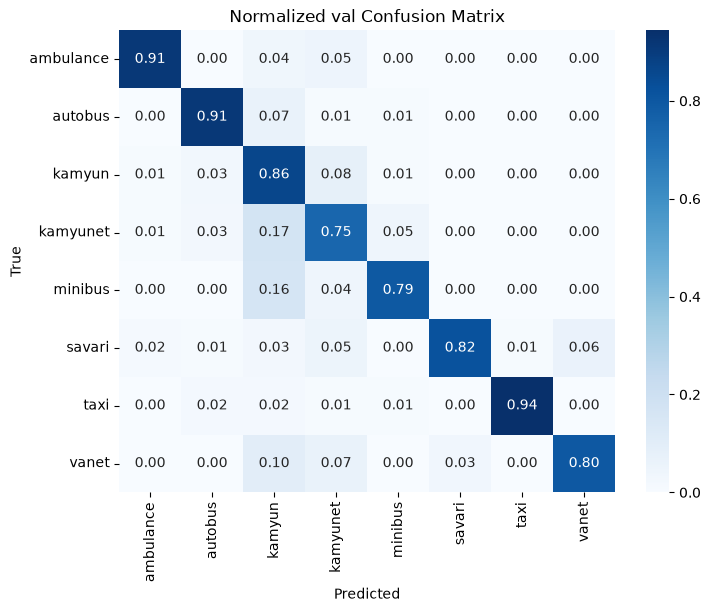

In [8]:
cm_normalized = confusion_matrix(
    all_val_labels,
    all_val_predictions,
    normalize="true"
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=train_data.classes,
    yticklabels=train_data.classes
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized val Confusion Matrix")

plt.show()